# Spot detection in fluorescence images

This notebook detects fluorescent spots in a 2-channel microscopy image and compute the
overlap (co-localization).

- **Channel 1**: DAPI (nuclear stain)
- **Channel 2**: GFP (protein of interest)

In [42]:
import os

import numpy as np
import tifffile
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from skimage.measure import label


## Load image

In [43]:
img = tifffile.imread("data/sample_image.tif")
print(img.shape)
print(img.dtype)

(2, 256, 256)
float64


## Process channel 0 (DAPI)

In [ ]:
from skimage.filters import gaussian, threshold_otsu, threshold_yen

det = 0
ch0 = img[0]

# subtract background
background0 = gaussian(ch0, sigma=20)
ch0_no_bg = ch0 - background0
ch0_no_bg[ch0_no_bg < 0] = 0
ch0_smooth = gaussian(ch0_no_bg, sigma=1.5)

# detect spots
if det == 0:
    ch0_spots = ch0_smooth > 200
elif det == 1:
    ch0_spots = ch0_smooth > threshold_otsu(ch0_smooth, nbins=128)
elif det == 2:
    ch0_spots = ch0_smooth > threshold_yen(ch0_smooth)

ch0_labeled = label(ch0_spots)
n_spots_ch0 = ch0_labeled.max()
print("DAPI spots:", n_spots_ch0)


DAPI spots: 6


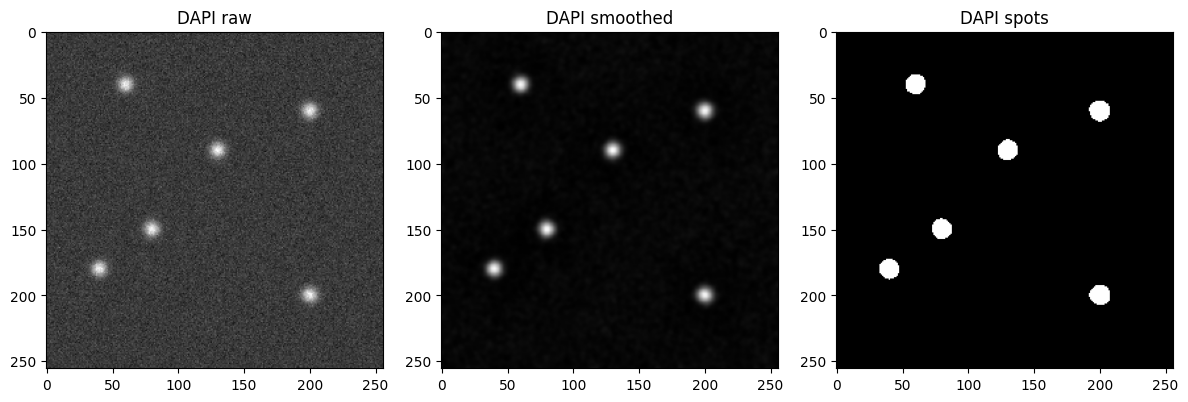

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(ch0, cmap="gray")
axes[0].set_title("DAPI raw")
axes[1].imshow(ch0_smooth, cmap="gray")
axes[1].set_title("DAPI smoothed")
axes[2].imshow(ch0_spots, cmap="gray")
axes[2].set_title("DAPI spots")
plt.tight_layout()
plt.show()

## Process channel 1 (GFP)

In [46]:
gfp = img[1]

# subtract background
bg = gaussian(gfp, sigma=25)
gfp_corrected = gfp - bg
gfp_corrected[gfp_corrected < 0] = 0

# smooth
gfp_smooth = gaussian(gfp_corrected, sigma=2.0)

# detect spots
# ch1_spots = gfp_smooth > 100  # tried 100, too many false positives
if det == 0:
    ch1_spots = gfp_smooth > 150
elif det == 1:
    ch1_spots = gfp_smooth > threshold_otsu(gfp_smooth, nbins=256)
elif det == 2:
    ch0_spots = gfp_smooth > threshold_yen(gfp_smooth)

ch1_labeled = label(ch1_spots)
n_ch1_spots = ch1_labeled.max()
print("GFP spots:", n_ch1_spots)


GFP spots: 4


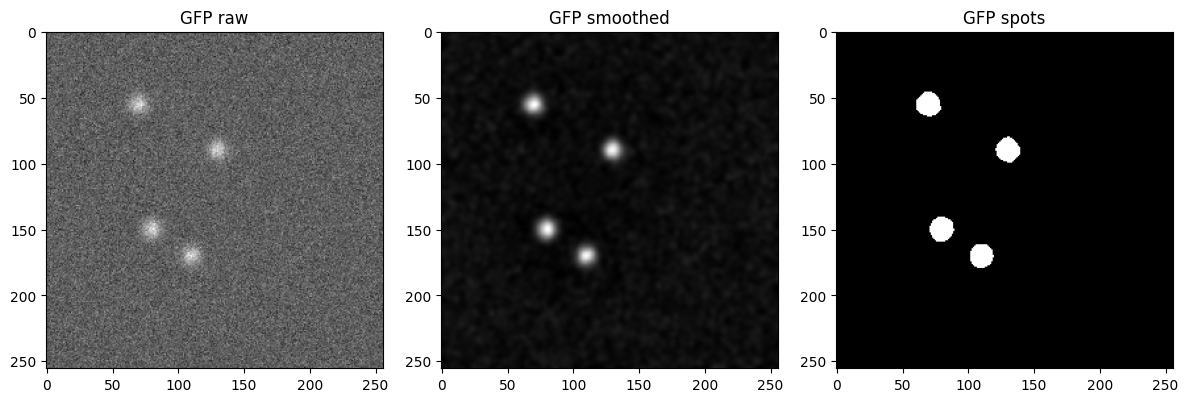

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(gfp, cmap="gray")
axes[0].set_title("GFP raw")
axes[1].imshow(gfp_smooth, cmap="gray")
axes[1].set_title("GFP smoothed")
axes[2].imshow(ch1_spots, cmap="gray")
axes[2].set_title("GFP spots")
plt.tight_layout()
plt.show()

## Statistics

In [48]:
# channel statistics (raw pixel values)
ch0_mean = np.mean(img[0])
ch0_std = np.std(img[0])
ch0_min = int(np.min(img[0]))
ch0_max = int(np.max(img[0]))

ch1_mean = np.mean(img[1])
ch1_std = np.std(img[1])
ch1_min = int(np.min(img[1]))
ch1_max = int(np.max(img[1]))

print("DAPI  -- mean: %.1f  std: %.1f  min: %d  max: %d" % (ch0_mean, ch0_std, ch0_min, ch0_max))
print("GFP   -- mean: %.1f  std: %.1f  min: %d  max: %d" % (ch1_mean, ch1_std, ch1_min, ch1_max))

# overlap between the two spot masks
overlap_mask = ch0_spots & ch1_spots
union_mask = ch0_spots | ch1_spots
n_overlap = int(np.sum(overlap_mask))
overlap_pct = 100.0 * n_overlap / int(np.sum(union_mask))

print("Overlap pixels: %d  (%.1f%% of union)" % (n_overlap, overlap_pct))

DAPI  -- mean: 328.1  std: 285.3  min: -654  max: 3505
GFP   -- mean: 516.7  std: 326.8  min: -989  max: 3016
Overlap pixels: 1081  (100.0% of union)


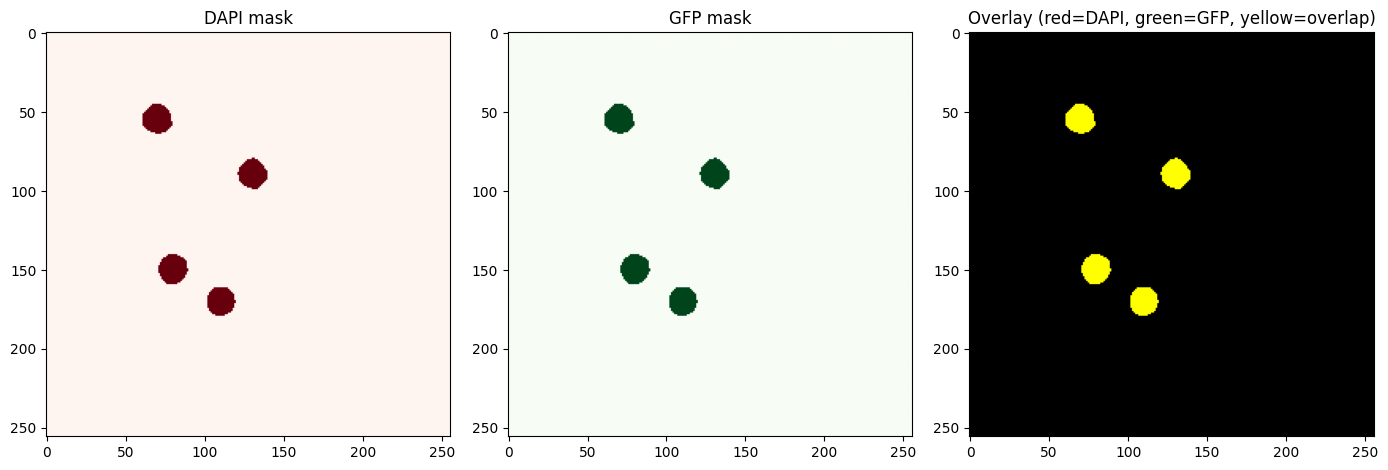

In [49]:
# Build an RGB composite: DAPI=red, GFP=green, overlap=yellow
rgb = np.zeros((img.shape[1], img.shape[2], 3), dtype=np.uint8)
rgb[ch0_spots, 0] = 255  # red channel  -> DAPI spots
rgb[ch1_spots, 1] = 255  # green channel -> GFP spots
# where both masks are true the pixel becomes yellow (red+green)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(ch0_spots, cmap="Reds")
axes[0].set_title("DAPI mask")
axes[1].imshow(ch1_spots, cmap="Greens")
axes[1].set_title("GFP mask")
axes[2].imshow(rgb)
axes[2].set_title("Overlay (red=DAPI, green=GFP, yellow=overlap)")
plt.tight_layout()
plt.show()

In [50]:
tifffile.imwrite("data/ch0_mask.tif", ch0_spots.astype(np.uint8))
tifffile.imwrite("data/ch1_mask.tif", ch1_spots.astype(np.uint8))

f = open("data/results.txt", "w")
f.write("=== Spot counts ===\n")
f.write("DAPI: " + str(int(n_spots_ch0)) + "\n")
f.write("GFP: " + str(int(n_ch1_spots)) + "\n")
f.write("\n")
f.write("=== Channel statistics ===\n")
f.write("DAPI mean: " + str(round(ch0_mean, 2)) + "\n")
f.write("DAPI std: " + str(round(ch0_std, 2)) + "\n")
f.write("DAPI min: " + str(ch0_min) + "\n")
f.write("DAPI max: " + str(ch0_max) + "\n")
f.write("GFP mean: " + str(round(ch1_mean, 2)) + "\n")
f.write("GFP std: " + str(round(ch1_std, 2)) + "\n")
f.write("GFP min: " + str(ch1_min) + "\n")
f.write("GFP max: " + str(ch1_max) + "\n")
f.write("\n")
f.write("=== Mask overlap ===\n")
f.write("Overlap pixels: " + str(n_overlap) + "\n")
f.write("Overlap percentage: " + str(round(overlap_pct, 1)) + "%\n")

27